Estimating Mean Radiant Temperature from LST and shadows at a precise moment, at 1m scale

Previously ---------- MRT = (LST + 10.2)/0.92 x (1-0.5 x shadows)

Now ---------------- MRT = (LST + 10.2)/0.92 - 10 * shadows

### General paths, libraries

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import CRS
import pandas as pd
from rasterio import features
from rasterio.transform import from_origin
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
from rasterstats import zonal_stats

In [2]:
shadows_vector_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/shadows_all_2024-08-09-095810.gpkg"
shadow_raster_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/shadows_all_2024-08-09-095810_1m.tif"  
lst_predicted_path = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/LST_predicted_RF.tif' 
lst_predicted_1m_path = "../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/LST_predicted_1m.tif"
mrt_output_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/MRT_1m.tif"
census_areas_path = "../../../datos-notebooks/sezioni-di-censimento-anno-2011.geojson"

### Preparing shadows (rasterizing-1m)

In [ ]:
shadow1 = gpd.read_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/original-shadows/shadows_buildings_2024-08-09_095810.gpkg") 
shadow1 = shadow1.to_crs(CRS.from_epsg(7791))
shadow2 = gpd.read_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/original-shadows/shadows_trees_2024-08-09_095810") 
shadow2 = shadow2.to_crs(CRS.from_epsg(7791))
shadow3 = gpd.read_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/original-shadows/origini-di-bologna-portici.geojson") 
shadow3 = shadow3.to_crs(CRS.from_epsg(7791))

# join all the shadow files in one
shadow = gpd.GeoDataFrame(pd.concat([shadow1, shadow2, shadow3], ignore_index=True), crs=shadow1.crs)
shadow.to_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/original-shadows/shadows_all_2024-08-09-095810.gpkg", layer="shadow", driver="GPKG")



In [ ]:
shadow=gpd.read_file(shadows_vector_path)

#preparing dataset for rasterizing
shadow = shadow[~shadow.geometry.is_empty] # Drop empty geometries
shadow = shadow[shadow.geometry.notnull()] # Drop null geometries
shadow["geometry"] = shadow.buffer(0) # Fix invalid geometries (buffer(0) trick)
shadow = shadow[~shadow.geometry.is_empty] # Drop again if something became empty


In [ ]:
#rasterizing 

res = 1  # pixel size in meters
minx, miny, maxx, maxy = shadow.total_bounds # bounds of the vector layer

# number of rows and cols
width  = int((maxx - minx) / res)
height = int((maxy - miny) / res)

# affine transform (top-left origin)
transform = from_origin(minx, maxy, res, res)

# geometry -> value 
shapes = ((geom, 1) for geom in shadow.geometry if geom is not None)

# rasterization
raster = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# Save raster ---
with rasterio.open(
    shadow_raster_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=raster.dtype,
    crs=shadow.crs,
    transform=transform
) as dst:
    dst.write(raster, 1)


In [3]:
with rasterio.open(shadow_raster_path) as src:
    shadow_raster = src.read(1)        
    transform = src.transform  
    crs = src.crs              


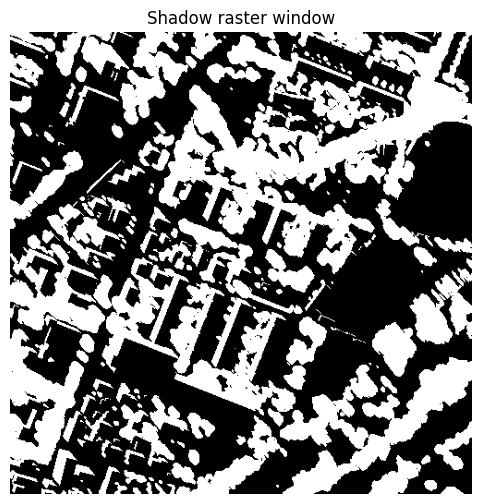

In [6]:
# Plot

xmin, ymin = 681000, 4945000
xmax, ymax = 681500, 4945500

win = from_bounds(xmin, ymin, xmax, ymax, transform) # Convert bounds to pixel window

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)

# Extract window
r_win = shadow_raster[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(6,6))
plt.imshow(r_win, cmap="gray", origin="upper")
plt.title("Shadow raster window")
plt.axis("off")
plt.show()


### Upscaling modeled LST to shadow resolution (1m)

In [11]:
with rasterio.open(shadow_raster_path) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

with rasterio.open(lst_predicted_path) as src:
    lst_1m = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=lst_1m,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear  # good for continuous variables like LST
    )

    meta = src.meta.copy()
    meta.update({
        "height": ref_shape[0],
        "width": ref_shape[1],
        "transform": ref_transform,
        "crs": ref_crs,
        "dtype": "float32"
    })

    with rasterio.open(lst_predicted_1m_path, "w", **meta) as dst:
        dst.write(lst_1m, 1)

### MRT estimation


In [ ]:
with rasterio.open(lst_predicted_1m_path) as lst, rasterio.open(shadow_raster_path) as sh:
    
    # Read data as float
    lst_arr = lst.read(1).astype("float32")
    sh_arr  = sh.read(1).astype("float32")
    
    # MRT formula
    mrt = ((lst_arr + 10.2) / 0.92) - 10 * sh_arr

    # Metadata from LST
    meta = lst.meta.copy()
    meta.update(dtype="float32", nodata=np.nan)

    # Save raster
    with rasterio.open(mrt_output_path, "w", **meta) as dst:
        dst.write(mrt, 1)


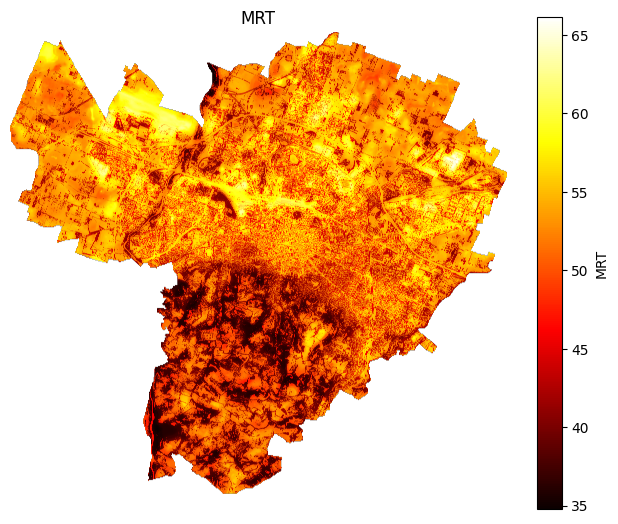

In [8]:
with rasterio.open(mrt_output_path) as src:
    mrt_plot = src.read(1) 

plt.figure(figsize=(8,8)) 
img = plt.imshow(mrt_plot, cmap="hot", origin="upper") #complete image, 1 minute aprox
plt.colorbar(img, shrink=0.8, label="MRT")
plt.axis("off")
plt.title("MRT")
plt.show()


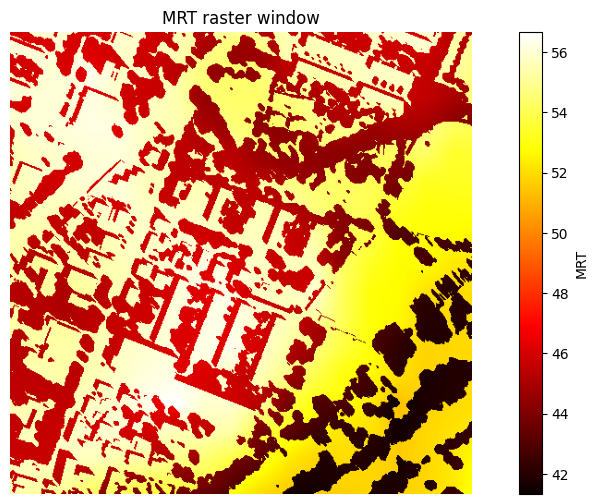

In [10]:
with rasterio.open(mrt_output_path) as src:
    mrt_1m = src.read(1)

xmin, ymin = 681000, 4945000
xmax, ymax = 681500, 4945500

# Convert bounds to pixel window
win = from_bounds(xmin, ymin, xmax, ymax, transform)

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)
r_win
# Extract window
r_win = mrt_1m[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(12,6))
plt.imshow(r_win, cmap="hot", origin="upper")
plt.title("MRT raster window")
plt.colorbar(label="MRT") #arreglar esto
plt.axis("off")
plt.show()



### Extracting results for census areas

In [ ]:
with rasterio.open(mrt_output_path) as src:
    mrt_pred = src.read(1)
    mrt_transform = src.transform
    mrt_crs = src.crs
    
census_areas = gpd.read_file(census_areas_path)
census_areas = census_areas.to_crs(mrt_crs)

In [ ]:
# Extract statistics
stats = zonal_stats(
    census_areas,
    mrt_output_path,
    stats=["min", "max", "mean"],
    nodata=None  # o poné el nodata real si tu raster lo tiene
)

# Create a new  nuevo GeoDataFrame with statistics + geometry
census_stats = gpd.GeoDataFrame({
    "min_MRT":  [s["min"]  for s in stats],
    "max_MRT":  [s["max"]  for s in stats],
    "mean_MRT": [s["mean"] for s in stats]
},
geometry=census_areas.geometry,
crs=census_areas.crs)


In [ ]:
census_stats.head()

In [ ]:
census_stats.to_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/MRT_census_areas.gpkg", driver="GPKG")

In [ ]:
gdf = gpd.read_file("../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/MRT_census_areas.gpkg")

fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column="mean_MRT", cmap="hot", legend=True, ax=ax, linewidth=0, edgecolor="none")
ax.set_title("Mean MRT")
ax.set_axis_off()
plt.show()


In [ ]:
plt.figure(figsize=(12,4))

# Min
plt.subplot(1,3,1)
plt.hist(census_stats["min_MRT"].dropna(), bins=20, color="red")
plt.title("Min MRT")
plt.xlabel("MRT")
plt.ylabel("Frecuency")

# Mean
plt.subplot(1,3,2)
plt.hist(census_stats["mean_MRT"].dropna(), bins=20, color="orange")
plt.title("Avg MRT")
plt.xlabel("MRT")

# Max
plt.subplot(1,3,3)
plt.hist(census_stats["max_MRT"].dropna(), bins=20, color="darkred")
plt.title("Max MRT")
plt.xlabel("MRT")

plt.tight_layout()
plt.show()
